# Credit Card Fraud: Black Box Robustness Audit

The two models trained in train_fraud.ipynb are loaded here as black boxes. The auditor only calls predict_proba, nothing else. The test set gets corrupted with increasing amounts of noise and we track how much worse each model gets. Same engine as the churn audit, second domain of the 2x2 matrix.

## Setup

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import train_test_split

## Rebuild the test set

Same split as the training notebook (same test_size, stratify and random_state), so we get the identical held out test set the models were evaluated on. All features are numeric so there is no encoding step, no train columns to lock, no reindex. The pipeline is simpler here than it was for churn.

In [2]:
df_fraud = pd.read_csv("../data/processed/creditcard_fraud_clean.csv")

In [3]:
x = df_fraud.drop("Class", axis=1)
y = df_fraud["Class"]

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.25, stratify=y, random_state=42
)
X_test_raw = X_test.copy()
print("Test set size:", len(X_test))
print("Feature count:", X_test_raw.shape[1])

Test set size: 71202
Feature count: 29


## Feature groups

Every column is numeric. Time is excluded from perturbation because it is a sequential index, not a measurement, and multiplying seconds since the first transaction by noise makes little sense. Amount and the V1 through V28 PCA components are all perturbed. There are no categorical features, so the swap engine sits unused.

In [5]:
numerical_features = list(col for col in X_test_raw.columns if col != "Time")
categorical_features = []

print("Numeric features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numeric features: 29
Categorical features: 0


## Load the frozen models

The LR file holds a whole Pipeline with its scaler inside, so raw input is fine. XGBoost was fitted on raw data. No internals are inspected anywhere in this notebook.

In [6]:
models = {
    "Logistic Regression": joblib.load("../outputs/models/fraud_logistic_regression.joblib"),
    "XGBoost": joblib.load("../outputs/models/fraud_xgboost.joblib"),
}

## Scoring helper

Same three rulers as churn, with one addition: the threshold for F1 is now a parameter. At 0.17 percent positives, almost no probability crosses 0.5, so F1 at the default threshold is zero for everything and tells us nothing.

In [7]:
def audit_metrics(model, X, y_true, threshold=0.5):
    """Score a black box model on one input matrix.

    Probabilities come from predict_proba. F1 uses the given threshold,
    ROC-AUC and PR-AUC use the raw probabilities. The default 0.5 is
    useless at this imbalance, so the audit passes each model's own
    optimal threshold instead.
    """
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

## Clean baselines and F1 thresholds

For each model we scan the precision recall curve and keep the threshold that maximises F1 on the clean test set. That per model threshold is then frozen and reused at every noise level, so F1 measures degradation, not threshold luck. The baselines should reproduce the training notebook scores.

In [8]:
thresholds = {}
print("Clean baselines:")
for model_name, model in models.items():
    y_proba = model.predict_proba(X_test_raw)[:, 1]
    precision, recall, thresh = precision_recall_curve(Y_test, y_proba)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best = np.argmax(f1_scores)
    thresholds[model_name] = thresh[best]
    m = audit_metrics(model, X_test_raw, Y_test, threshold=thresholds[model_name])
    print(f"  {model_name}: {m}  (threshold {thresholds[model_name]:.4f})")

Clean baselines:
  Logistic Regression: {'f1': 0.8170212765957446, 'roc_auc': 0.9727435990436383, 'pr_auc': 0.7046889021683458}  (threshold 1.0000)
  XGBoost: {'f1': 0.8584070796460177, 'roc_auc': 0.9666585341833664, 'pr_auc': 0.8338681247877469}  (threshold 0.3444)


## Perturbation engine

Same mechanics as churn. Numeric columns get multiplicative noise, each value multiplied by 1 + U(-rate, rate). The categorical swap function is kept so the engine stays identical across domains, but the categorical list here is empty and it never runs. One shared seeded RNG drives everything, and each noise level is corrupted once so both models score the same corrupted copy.

In [9]:
def perturb_numeric(df, features, rate, rng):
    """Scale numeric features by multiplicative noise.

    Every value is multiplied by 1 + U(-rate, rate), a relative deviation
    of up to rate in either direction, drawn independently per row.
    """
    df_perturbed = df.copy()
    for feature in features:
        noise = 1 + rng.uniform(-rate, rate, size=len(df_perturbed))
        df_perturbed[feature] = df_perturbed[feature] * noise
    return df_perturbed

In [10]:
def perturb_categorical(df, features, rate, rng):
    """Swap a fraction of categorical values with fresh draws.

    Exactly rate of rows per column are selected and their value is
    replaced by a draw from the column's own value distribution. The
    current value is excluded from the draw pool so every swap changes
    the field. Unused in this domain, the categorical list is empty.
    """
    df_perturbed = df.copy()
    for feature in features:
        probs = df_perturbed[feature].value_counts(normalize=True)
        n_swap = int(round(len(df_perturbed) * rate))
        swap_idx = rng.choice(len(df_perturbed), size=n_swap, replace=False)
        values = df_perturbed[feature].to_numpy(copy=True)
        for i in swap_idx:
            p = probs.copy()
            p[values[i]] = 0.0
            p = p / p.sum()
            values[i] = rng.choice(p.index, p=p.values)
        df_perturbed[feature] = values
    return df_perturbed

In [11]:
def corrupt_data(df, numeric_features, categorical_features, numeric_rate, categorical_rate, rng):
    """Apply one stepped noise level to a raw data frame.

    Numeric features get multiplicative noise, categorical features get
    swaps. The same RNG drives both so the corruption stream stays
    reproducible.
    """
    df_perturbed = perturb_numeric(df, numeric_features, numeric_rate, rng)
    df_perturbed = perturb_categorical(df_perturbed, categorical_features, categorical_rate, rng)
    return df_perturbed

## Audit loop

For every noise level: corrupt the raw test frame, score both models, record the numbers. Level 0 is the clean reference. No encoding step, just corrupt and predict.

In [12]:
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20]

rng = np.random.default_rng(seed=42)

records = []
for level in NOISE_LEVELS:
    if level == 0:
        dirty_frame = X_test_raw
    else:
        dirty_frame = corrupt_data(
            X_test_raw, numerical_features, categorical_features, level, level, rng
        )
    for name, model in models.items():
        metrics = audit_metrics(model, dirty_frame, Y_test, threshold=thresholds[name])
        metrics["model"] = name
        metrics["noise_level"] = level
        records.append(metrics)

results = pd.DataFrame(records)
results

,f1,roc_auc,pr_auc,model,noise_level
0,0.817021,0.972744,0.704689,Logistic Regression,0.00
1,0.858407,0.966659,0.833868,XGBoost,0.00
2,0.811966,0.972230,0.706845,Logistic Regression,0.05
3,0.858407,0.966074,0.837880,XGBoost,0.05
4,0.811966,0.972433,0.702968,Logistic Regression,0.10
5,0.832618,0.966109,0.834085,XGBoost,0.10
6,0.805085,0.971567,0.704315,Logistic Regression,0.20
7,0.836820,0.968493,0.843549,XGBoost,0.20


## Relative degradation

Each score divided by that model's own clean score, expressed as a percentage drop. PR-AUC is the honest metric at this imbalance, ROC-AUC is inflated by the sea of true negatives.

In [13]:
clean = results[results["noise_level"] == 0.0][["model", "roc_auc", "f1", "pr_auc"]].rename(
    columns={"roc_auc": "roc_auc_clean", "f1": "f1_clean", "pr_auc": "pr_auc_clean"}
)

merged = results.merge(clean, on="model")
for metric in ["roc_auc", "f1", "pr_auc"]:
    merged[f"{metric}_pct_drop"] = (1 - merged[metric] / merged[f"{metric}_clean"]) * 100

table = merged[merged["noise_level"] > 0].pivot(
    index="noise_level", columns="model",
    values=["roc_auc_pct_drop", "f1_pct_drop", "pr_auc_pct_drop"],
)
table.round(2)

roc_auc_pct_drop                 f1_pct_drop          \
model       Logistic Regression XGBoost Logistic Regression XGBoost   
noise_level                                                           
0.05                       0.05    0.06                0.62    0.00   
0.10                       0.03    0.06                0.62    3.00   
0.20                       0.12   -0.19                1.46    2.51   

                pr_auc_pct_drop          
model       Logistic Regression XGBoost  
noise_level                              
0.05                      -0.31   -0.48  
0.10                       0.24   -0.03  
0.20                       0.05   -1.16

## Save results

In [14]:
os.makedirs("../outputs/results", exist_ok=True)
results.to_csv("../outputs/results/fraud_audit_results.csv", index=False)
print("Results saved.")

Results saved.


## Degradation curves

PR-AUC comes first this time because it is the metric that actually cares about the rare positives. The result is striking: neither model degrades. Every drop stays under 3 percent and some scores even wobble upward. The likely reason is the data representation. The V columns are PCA components centered on zero, and multiplicative noise never flips a sign and barely moves small values, so the extreme values that mark fraud stay extreme. The same nominal noise level that broke XGBoost on churn is nearly harmless here, which says the effective strength of a perturbation depends on the representation, not just the percentage on the label.

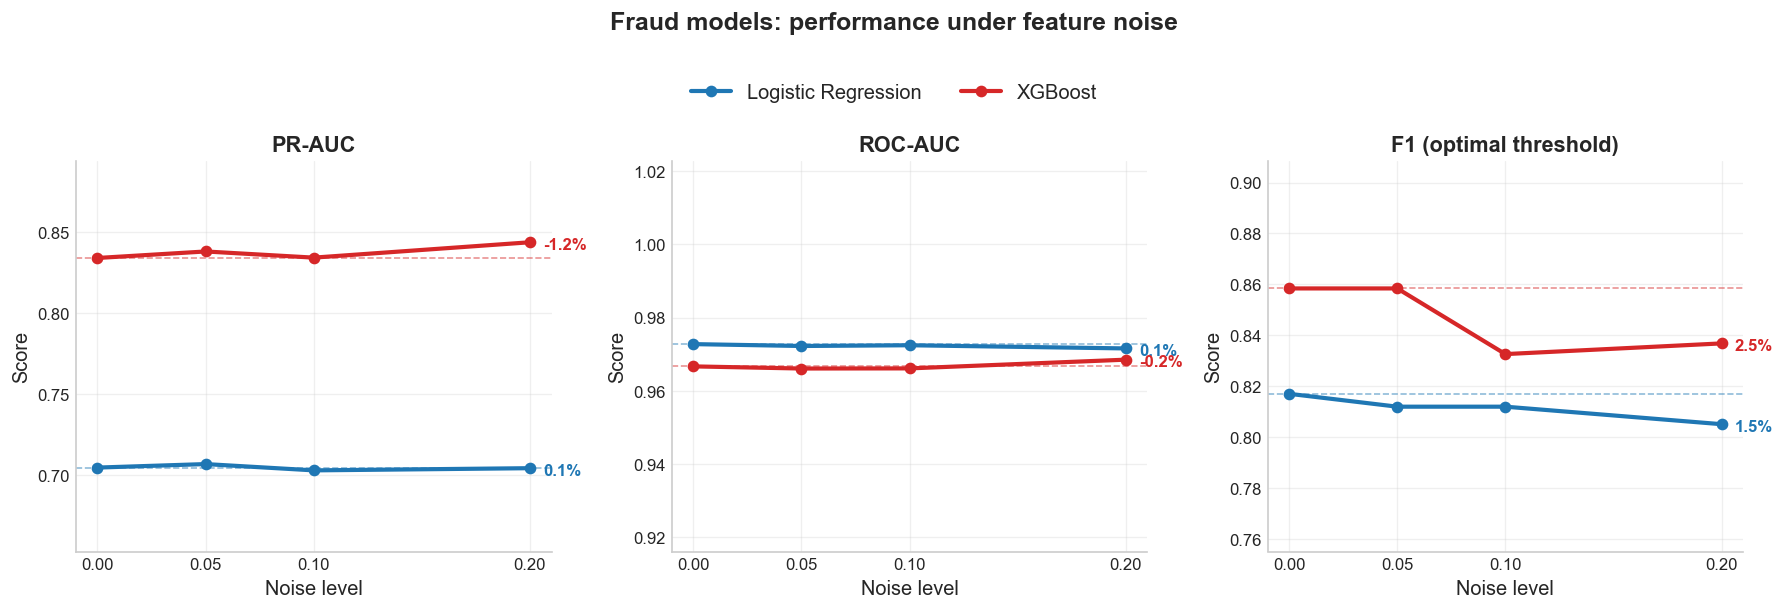

In [15]:
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {"Logistic Regression": "#1f77b4", "XGBoost": "#d62728"}

metric_order = ["pr_auc", "roc_auc", "f1"]
titles = ["PR-AUC", "ROC-AUC", "F1 (optimal threshold)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)

for ax, metric, title in zip(axes, metric_order, titles):
    all_vals = []
    for name in models:
        sub = results[results["model"] == name].sort_values("noise_level")
        baseline = sub.iloc[0][metric]
        ax.axhline(baseline, color=COLORS[name], linestyle="--", linewidth=1, alpha=0.5)
        ax.plot(
            sub["noise_level"], sub[metric],
            marker="o", markersize=6, linewidth=2.5,
            color=COLORS[name], label=name,
        )
        all_vals.extend(sub[metric])
        last = sub.iloc[-1]
        drop = (1 - last[metric] / baseline) * 100 if baseline > 0 else 0
        ax.annotate(
            f"{drop:.1f}%",
            (last["noise_level"], last[metric]),
            textcoords="offset points", xytext=(8, -4),
            fontsize=10, color=COLORS[name], fontweight="bold",
        )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Noise level", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    lo = min(all_vals) - 0.05
    hi = max(all_vals) + 0.05
    ax.set_ylim(max(lo, -0.05), min(hi, 1.05))
    ax.set_xticks([0.0, 0.05, 0.10, 0.20])
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02),
           ncol=2, frameon=False, fontsize=12)

fig.suptitle("Fraud models: performance under feature noise", fontsize=15, fontweight="bold", y=1.12)
fig.tight_layout()
os.makedirs("../outputs/figures", exist_ok=True)
fig.savefig("../outputs/figures/fraud_degradation_curves.png", dpi=150, bbox_inches="tight")
plt.show()